# Lire le dataset issu de l'étape exploration

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
df = pd.read_csv("../data/processed/step1_exploration.csv")
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

print("Shape:", df.shape)
df.head()

Shape: (4372, 52)


,customerid,recency,frequency,monetarytotal,monetaryavg,monetarystd,monetarymin,monetarymax,totalquantity,avgquantitypertransaction,...,region,loyaltylevel,churnriskcategory,weekendpreference,basketsizecategory,productdiversity,gender,accountstatus,country,churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,...,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,...,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


 1. Diagnostic global

✔️ Types et valeurs manquantes

In [145]:
df.info()
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("Colonnes avec valeurs manquantes :")
print(missing)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4372 entries, 0 to 4371
Data columns (total 52 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 4372 non-null   int64  
 1   recency                    4372 non-null   int64  
 2   frequency                  4372 non-null   int64  
 3   monetarytotal              4372 non-null   float64
 4   monetaryavg                4372 non-null   float64
 5   monetarystd                4372 non-null   float64
 6   monetarymin                4372 non-null   float64
 7   monetarymax                4372 non-null   float64
 8   totalquantity              4372 non-null   int64  
 9   avgquantitypertransaction  4372 non-null   float64
 10  minquantity                4372 non-null   int64  
 11  maxquantity                4372 non-null   int64  
 12  customertenuredays         4372 non-null   int64  
 13  firstpurchasedaysago       4372 non-null   int64

✔️ Visualisation des NaN

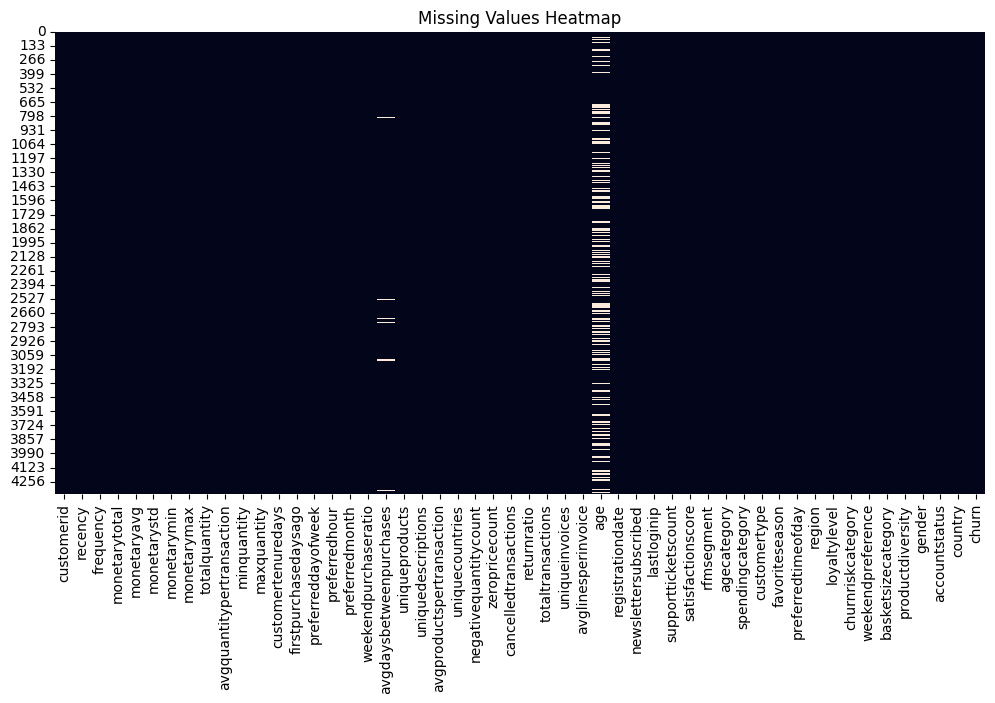

In [146]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Nettoyage des valeurs manquantes


1. Age (30% manquant)


In [147]:
median_age = df['age'].median() #calcule la médiane des âges
df['age'] = df['age'].fillna(median_age) #remplace les valeurs manquantes par médiane

2. AvgDaysBetweenPurchases

In [148]:
df['avgdaysbetweenpurchases'] = df['avgdaysbetweenpurchases'].fillna(
    df['avgdaysbetweenpurchases'].median()
)

<!-- 3. MonetaryTotal_log -->

In [149]:
# # df['MonetaryTotal_log'] = np.log1p(df['MonetaryTotal'])
# df = df.fillna(df.median(numeric_only=True))


4. SupportTickets

In [150]:
df['supportticketscount'] = df['supportticketscount'].replace([-1, 999], np.nan) #remplace les valeurs aberrantes par NaN
df['supportticketscount'] = df['supportticketscount'].fillna(df['supportticketscount'].median()) #remplace les valeurs manquantes par la médiane
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())


5. Satisfaction

In [151]:
df["satisfactionscore"] = df["satisfactionscore"].replace([-1, 99], np.nan) #où tu vois -1 ou 99, efface-les et mets 'vide' (NaN)
df["satisfactionscore"] = df["satisfactionscore"].fillna(df["satisfactionscore"].median()) #remplir les vides". On utilise la médiane

# Vérification intermédiaire

In [152]:
df.isnull().sum().sort_values(ascending=False) 
#Vérifie combien de NaN restent par colonne après le traitement.
#sort_values(ascending=False) affiche d’abord les colonnes avec le plus de valeurs manquantes

customerid                   0
recency                      0
frequency                    0
monetarytotal                0
monetaryavg                  0
monetarystd                  0
monetarymin                  0
monetarymax                  0
totalquantity                0
avgquantitypertransaction    0
minquantity                  0
maxquantity                  0
customertenuredays           0
firstpurchasedaysago         0
preferreddayofweek           0
preferredhour                0
preferredmonth               0
weekendpurchaseratio         0
avgdaysbetweenpurchases      0
uniqueproducts               0
uniquedescriptions           0
avgproductspertransaction    0
uniquecountries              0
negativequantitycount        0
zeropricecount               0
cancelledtransactions        0
returnratio                  0
totaltransactions            0
uniqueinvoices               0
avglinesperinvoice           0
age                          0
registrationdate             0
newslett

# Traitement des valeurs aberrantes

✔️ Visualisation

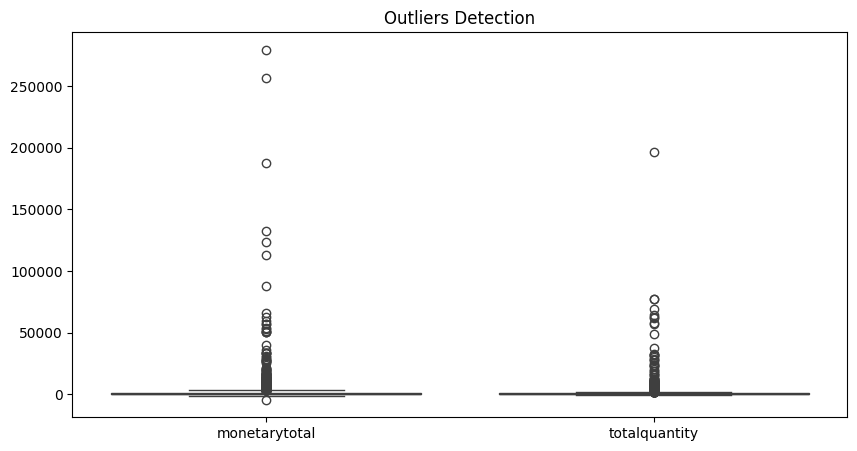

In [153]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['monetarytotal', 'totalquantity']])
plt.title("Outliers Detection")
plt.show()

✔️ Correction

In [154]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[col].clip(lower, upper)
cols_outliers = ['monetarytotal', 'totalquantity', 'frequency']

for col in cols_outliers:
    df[col] = remove_outliers_iqr(df, col)



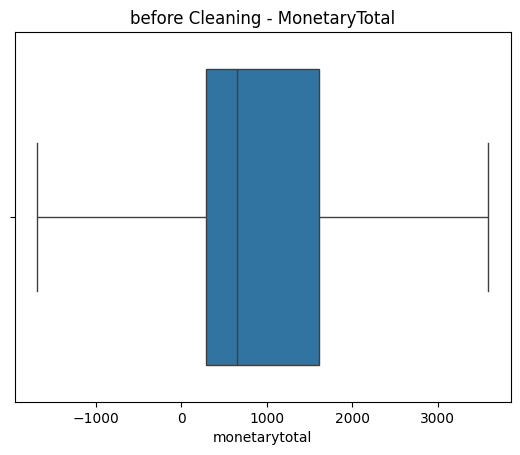

In [155]:
sns.boxplot(x=df['monetarytotal'])
plt.title("before Cleaning - MonetaryTotal")
plt.show()
# sns.boxplot(x=df['monetarytotal_log'])
# plt.title("After Log Transformation")
# plt.show()


# Suppression des features inutiles
1. NewsletterSubscribed (valeur constante)

In [156]:
df.drop("newslettersubscribed", axis=1, inplace=True)

print("newslettersubscribed" in df.columns) 


False


2. LastLoginIP

In [157]:
df.drop("lastloginip", axis=1, inplace=True)

print("lastloginip" in df.columns)

False


# Parsing de RegistrationDate
1. Convertir en format date

In [158]:
df["registrationdate"] = pd.to_datetime(
    df["registrationdate"],#cible
    dayfirst=True,#tu forces Python à comprendre que le premier chiffre est le Jou
    errors="coerce"
)

# Vérifier le type de la colonne
print(f"Nouveau type de la colonne : {df['registrationdate'].dtype}")

# Vérifier s'il y a eu des erreurs de conversion (NaT)
print(f"Nombre d'erreurs de date : {df['registrationdate'].isnull().sum()}")

Nouveau type de la colonne : datetime64[ns]
Nombre d'erreurs de date : 0


C:\Users\chaie\AppData\Local\Temp\ipykernel_4436\1555075546.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["registrationdate"] = pd.to_datetime(


2. Extraction

In [159]:
df['regyear'] = df['registrationdate'].dt.year
df['regmonth'] = df['registrationdate'].dt.month
df['regday'] = df['registrationdate'].dt.day
df['regweekday'] = df['registrationdate'].dt.weekday


In [160]:
df[['regyear', 'regmonth', 'regday', 'regweekday']] = df[
    ['regyear', 'regmonth', 'regday', 'regweekday']
].fillna(0)


3. Suppression

In [161]:
df.drop(columns=['registrationdate'], inplace=True)

In [162]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("unknown")
    
df['monetarytotal'] = df['monetarytotal'].clip(lower=0)
df['totalquantity'] = df['totalquantity'].clip(lower=0)


# Visualisation pour valider le nettoyage

In [163]:
print("NaN restants :", df.isnull().sum().sum())

assert df.isnull().sum().sum() == 0, "Il reste des NaN !"

print("Valeurs négatives :")
for col in ['monetarytotal', 'totalquantity']:
    print(col, (df[col] < 0).sum())

df.isnull().sum()
print("Shape final :", df.shape)
df.describe()
df[df.isnull().any(axis=1)]

print("Dataset prêt pour feature engineering et suppression corrélation")



NaN restants : 0
Valeurs négatives :
monetarytotal 0
totalquantity 0
Shape final : (4372, 53)
Dataset prêt pour feature engineering et suppression corrélation


# Sauvegarde

In [164]:
df.to_csv("../data/processed/step2_cleaning.csv", index=False)
print(f"Données sauvegardées ")

Données sauvegardées 


In [165]:
print("""
Cleaning terminé :

- Données sans NaN
- Outliers traités
- Colonnes inutiles supprimées
- Dataset prêt pour feature engineering
""")



Cleaning terminé :

- Données sans NaN
- Outliers traités
- Colonnes inutiles supprimées
- Dataset prêt pour feature engineering

